In [18]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [19]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [20]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [21]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }
def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


In [22]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}





class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start
#TODO1
    def is_goal(self, state: Tuple[int, int]) -> bool:
       return state == self.goal

       

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:

        #TODO2
        legal_actions=[]
        row, col =state
        for action, (dr, dc) in MOVES.items():
            neighbor = (row+dr, col+dc)
            if self.in_bounds(neighbor) and self.is_free(neighbor):
                legal_actions.append(action)
        return legal_actions

       
      

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
       #TODO3
    
            row, col = state
            dr, dc = MOVES[action]
            return (row+dr, col+dc)


#TODO4
    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        
        return 1

In [23]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
   
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [24]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape
    print(arr.shape)

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

(10, 10)


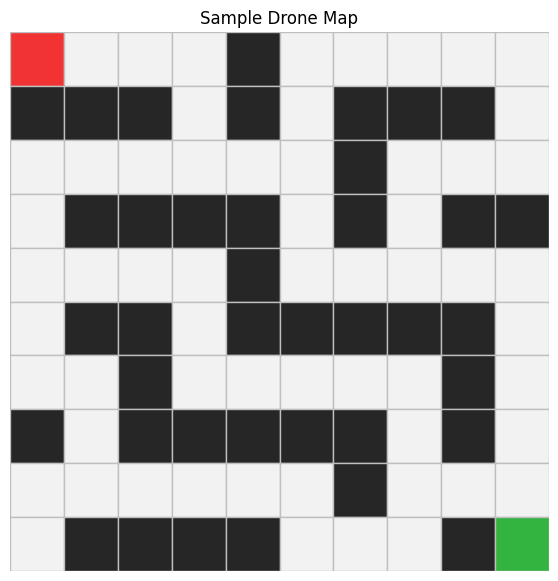

In [25]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")


In [26]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO5:
        
        s= node.state# current state
        for action in problem.actions(s): # for every possible action it can take
            s_prime = problem.result(s,action) # apply action to get new state
            cost=node.path_cost+problem.action_cost(s,action,s_prime)
            yield Node(state=s_prime,parent=node,action=action,path_cost=cost)

       
    

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [27]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
         

        # TODO6:
        nodes_expanded = 0
        max_frontier_size = 1
       
        
        #  Create the initial node from problem.initial_state().
        node = Node(problem.initial_state())
        # f the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(
                            algorithm=algorithm,
                            status="success",
                            solution=node,
                            nodes_expanded=nodes_expanded,
                            max_frontier_size=1,
                            reached_count=1,
                        )
        

        # 3. Create a deque frontier and add the initial node.
        frontier = deque([node])
        # 4. Create a reached set and add the initial state.
        reached ={problem.initial_state()}
        # 5. While frontier is not empty:
        while frontier:
               
        #       a. pop from the LEFT of the deque.
            node=frontier.popleft()
        #       b. increment nodes_expanded.
            nodes_expanded+=1
        #       c. expand the node.
        #       d. for each child:

        #            i. if child is goal, return success.
            for child in self.expand(problem,node):
                s=child.state
                if problem.is_goal(s):
                    return SearchResult(
                            algorithm=algorithm,
                            status="success",
                            solution=child,
                            nodes_expanded=nodes_expanded,
                            max_frontier_size = max(max_frontier_size, len(frontier)),
                            reached_count=len(reached),
                            )

        #           ii. if child.state is not in reached:
                if  s not in reached:


        #                 add child.state to reached.
                    reached.add(s)


        #                  append child to frontier.
                    frontier.append(child)
        #       e. update max_frontier_size.
            max_frontier_size = max(max_frontier_size, len(frontier))
        # 6. Return failure if no solution is found.
        return SearchResult(
                            algorithm=algorithm,
                            status="failure",
                            solution=None,
                            nodes_expanded=nodes_expanded,
                            max_frontier_size = max(max_frontier_size, len(frontier)),
                            reached_count=len(reached),
                            )
       

In [28]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"
        nodes_expanded = 0
        max_frontier_size = 1

        node = Node(problem.initial_state())

        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=1,
            )

        frontier = [node]
        reached = {node.state}

        while frontier:
            node = frontier.pop()
            nodes_expanded += 1

            children = list(self.expand(problem,node))
            for child in reversed(children):
            
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max(max_frontier_size, len(frontier)),
                        reached_count=len(reached),
                    )
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

In [29]:
#TODO8
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
            "reached_count": 0,
        }
        reached = {initial_node.state}

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=metrics["max_stack_size"],
            reached=reached,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=len(reached),
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
        reached: set,
    ) -> Tuple[Optional[Node], str]:
        metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size)
        if problem.is_goal(node.state):
            return  node,"success",

                
            
        elif (node.depth>=limit):
            return None,"cutoff"
                
        else:
            metrics["nodes_expanded"]+=1
            cutoff_occurred =False
        for child in self.expand(problem, node):
            reached.add(child.state)
            
            result, status = self._recursive_dls(
                problem= problem,
                node=child,
                limit=limit,
                metrics=metrics,
                current_stack_size=current_stack_size + 1,
                reached=reached,

                
                
            )
            if status=="success" :
                return result,status,
                

            elif status=="cutoff":
                cutoff_occurred=True
        if cutoff_occurred:
            return None,"cutoff"
        else:
            return None,"failure"

In [30]:
#TODO9
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log=[]
        total_nodes_expanded =0
        max_stack_size_seen =0
        total_reached_count = 0
        dls = DepthLimitedSearch()

        for limit in range(max_depth+1):
            result = dls.search(problem,limit=limit)
            total_nodes_expanded+= result.nodes_expanded
            max_stack_size_seen = max(max_stack_size_seen, result.max_frontier_size)
            total_reached_count = max(total_reached_count, result.reached_count)

            #iterating log
            iteration_log.append({"limit":limit, "status":result.status})

            #resukt for success
            if result.status=="success":
                return SearchResult(
            algorithm=algorithm,
            status="success",
            solution=result.solution,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size_seen,
            reached_count=total_reached_count,
            limit=limit,
            iterations = iteration_log,
        )
            
            #result for failure
            elif result.status =="failure":
                return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size_seen,
            reached_count=total_reached_count,
            limit=limit,
            iterations = iteration_log,
        )
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size_seen,
            reached_count=total_reached_count,
            limit=max_depth,
            iterations = iteration_log,
        )

In [31]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem),
    ids.search(problem),

]

#
      





show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,313,11,19
3,IDS,success,18.0,18.0,18.0,219263,19,53


In [32]:
# TODO10:
# Create your first custom map here.

custom_grid_1 = [
    [0,0,0],
    [0,0,0],
    [1,0,1]
]

custom_start_1 = (0,0)
custom_goal_1 = (1,1)



#xample after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
   bfs.search(custom_problem_1),
   dfs.search(custom_problem_1),
   dls.search(custom_problem_1, limit=20),
   ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,2,2,2,2,3
1,DFS,success,NaN,2,2,2,2,3
2,DLS,success,20.0,20,20,20,21,3
3,IDS,success,2.0,2,2,3,3,3


In [33]:
# TODO11:
# Create your second custom map here.

custom_grid_2 = [
    [0,0,0,0,0],
    [0,0,0,0,0],
    [0,0,0,0,0],
    [0,0,1,0,0],
    [0,0,0,0,0],
]

custom_start_2 = (0,0)
custom_goal_2 = (4,4)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=50),
    ids.search(custom_problem_2, max_depth=40),
 ]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,8,8,22,5,23
1,DFS,success,NaN,8,8,8,5,12
2,DLS,success,50.0,50,50,525,51,23
3,IDS,success,8.0,8,8,1804,9,23


(10, 10)


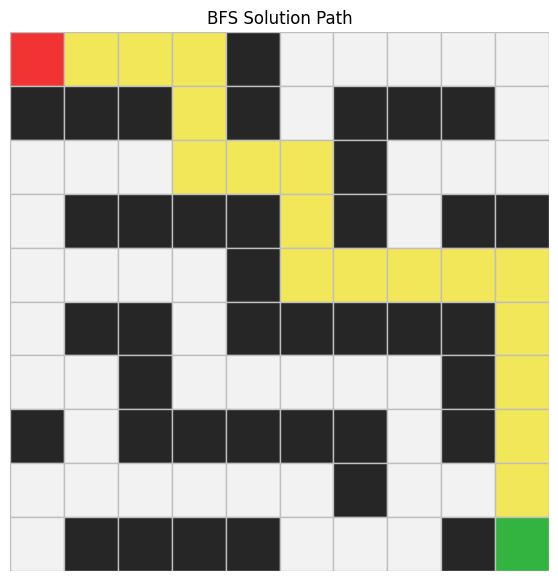

(10, 10)


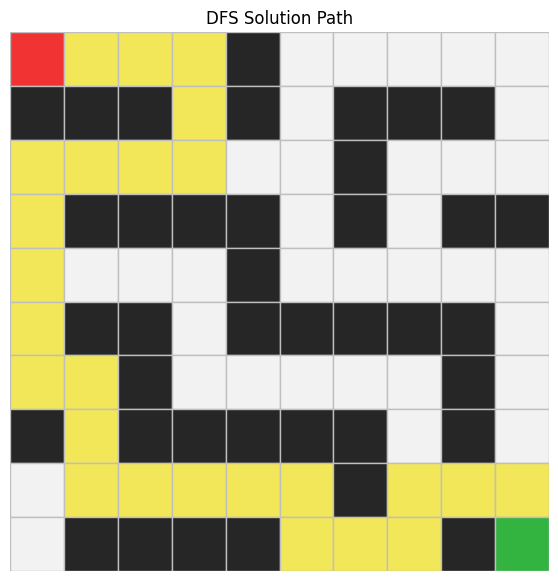

In [34]:
bfs_result = results[0]
dfs_result = results[1]


plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)
